# Statistical Tests for Confidence Experiments

Unblocked difference-in-means permutation test on both `response` and `confidence` score columns.

Test statistic:
$$T = \bar{X}_{\text{alt}} - \bar{X}_{\text{null}}$$

We pool all observations for a dataset, shuffle the alt/null labels, recompute $T$, and repeat.

P-value uses the Phipson & Smyth (2010) small-sample correction:
$$p = \frac{\#\{T_{\pi} \ge T_{\text{obs}}\} + 1}{B + 1}.$$

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

BASE_DIR = Path("..").resolve()
CSV_PATH = BASE_DIR / "aggregated_results" / "aggregated_results.csv"
N_PERM = 10_000

In [ ]:
if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"Expected aggregated results at {CSV_PATH}. "
        "Run scripts/aggregate_conclusions.py first."
    )

df = pd.read_csv(CSV_PATH, keep_default_na=False)
df["confidence"] = pd.to_numeric(df["confidence"], errors="coerce")
datasets = sorted(df["dataset"].unique())
print(f"{len(df)} rows, {len(datasets)} datasets: {datasets}")
print(f"  confidence missing: {df['confidence'].isna().sum()}")
df.head()

In [8]:
def diff_in_means_perm_test(
    alt: np.ndarray, null: np.ndarray, n_perm: int = N_PERM,
    rng: np.random.Generator | None = None,
) -> tuple[float, float, np.ndarray]:
    """Unblocked difference-in-means permutation test.

    Returns (observed_T, p_value, permuted_T_array).
    """
    if rng is None:
        rng = np.random.default_rng()
    n_alt = len(alt)
    pooled = np.concatenate([alt, null]).astype(float)
    t_obs = float(pooled[:n_alt].mean() - pooled[n_alt:].mean())

    # vectorized shuffle via argsort of random matrix
    n = len(pooled)
    perms = np.argsort(rng.random((n_perm, n)), axis=1)
    perm_ts = (
        np.mean(pooled[perms[:, :n_alt]], axis=1)
        - np.mean(pooled[perms[:, n_alt:]], axis=1)
    )

    p_value = ((perm_ts >= t_obs).sum() + 1) / (n_perm + 1)
    return t_obs, p_value, perm_ts

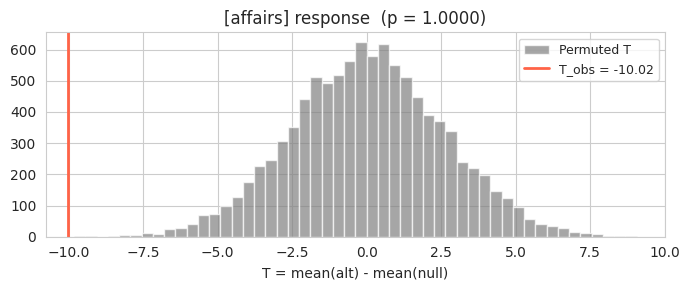

affairs [response]: T=-10.02  p=1.0000


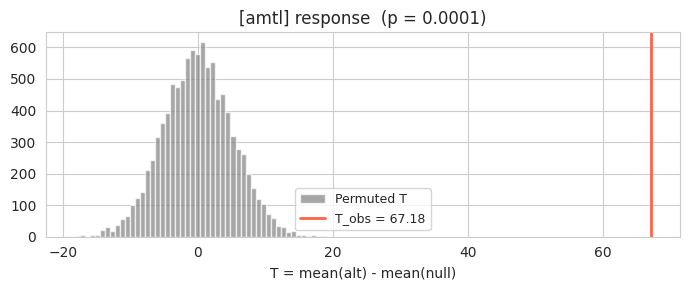

amtl [response]: T=67.18  p=0.0001


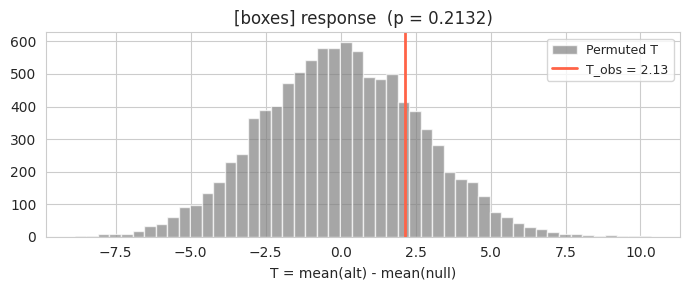

boxes [response]: T=2.13  p=0.2132


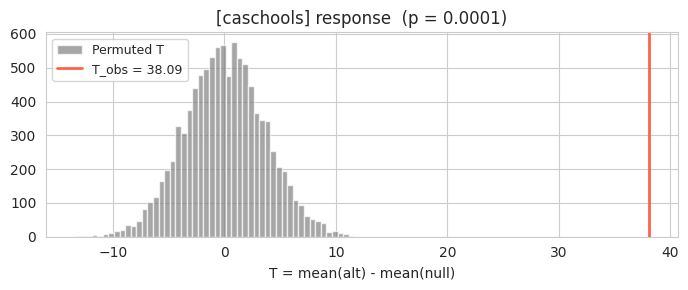

caschools [response]: T=38.09  p=0.0001


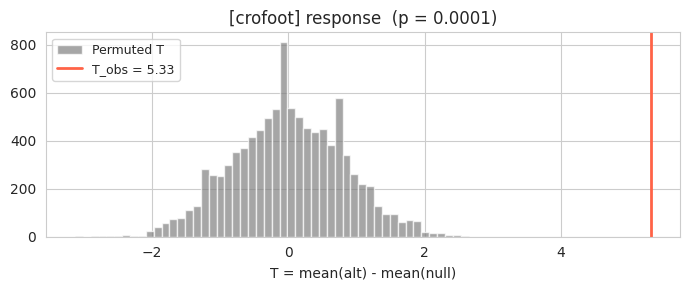

crofoot [response]: T=5.33  p=0.0001


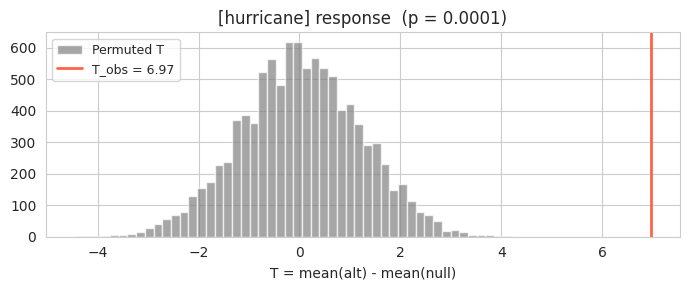

hurricane [response]: T=6.97  p=0.0001


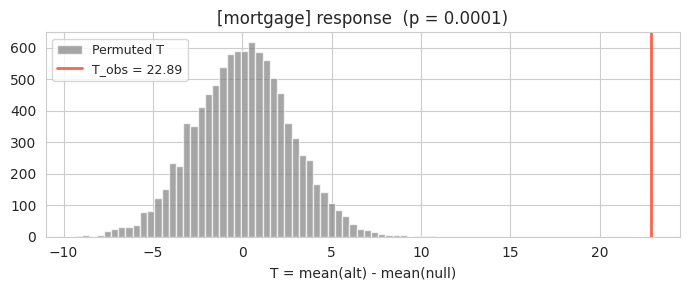

mortgage [response]: T=22.89  p=0.0001


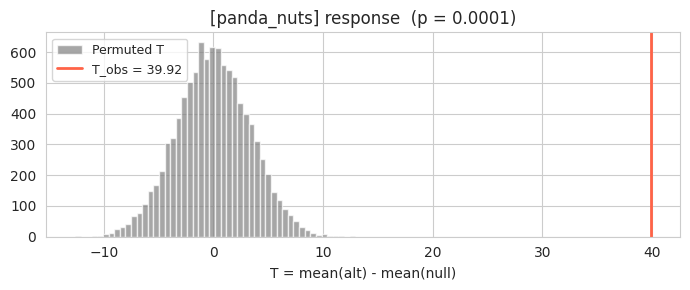

panda_nuts [response]: T=39.92  p=0.0001


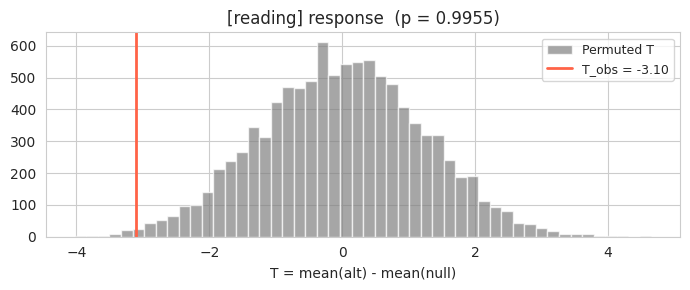

reading [response]: T=-3.10  p=0.9955


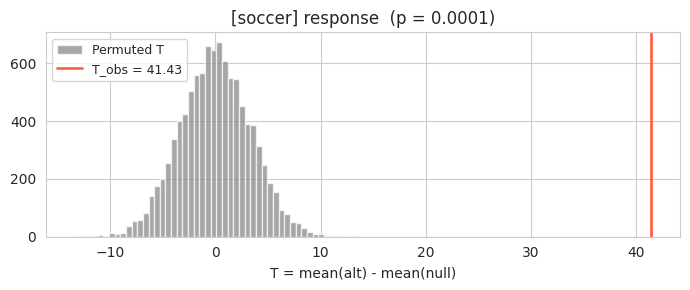

soccer [response]: T=41.43  p=0.0001


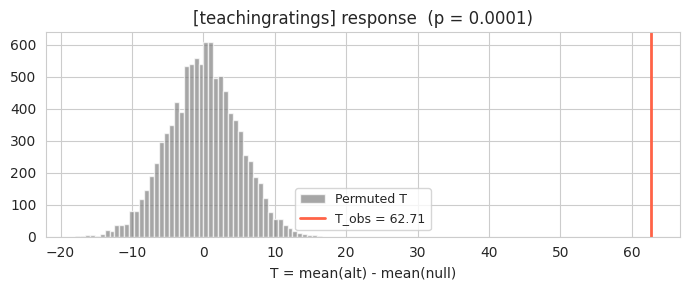

teachingratings [response]: T=62.71  p=0.0001


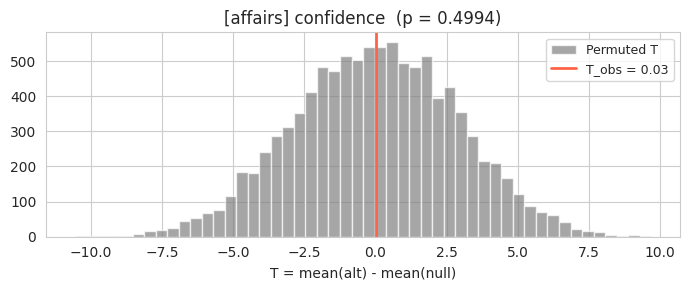

affairs [confidence]: T=0.03  p=0.4994


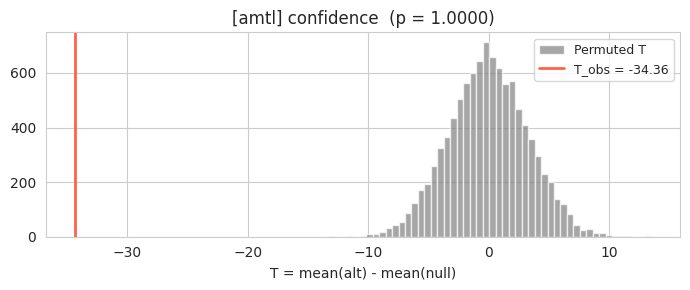

amtl [confidence]: T=-34.36  p=1.0000


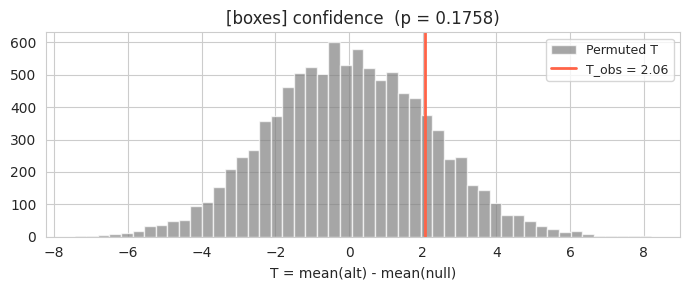

boxes [confidence]: T=2.06  p=0.1758


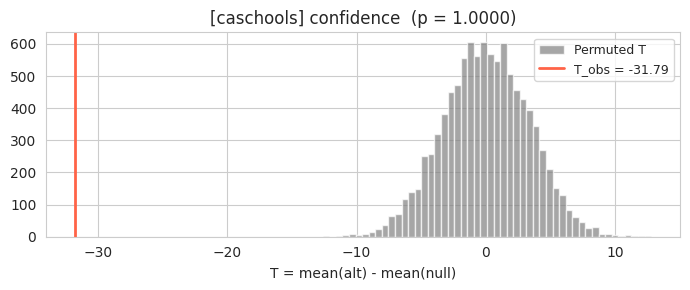

caschools [confidence]: T=-31.79  p=1.0000


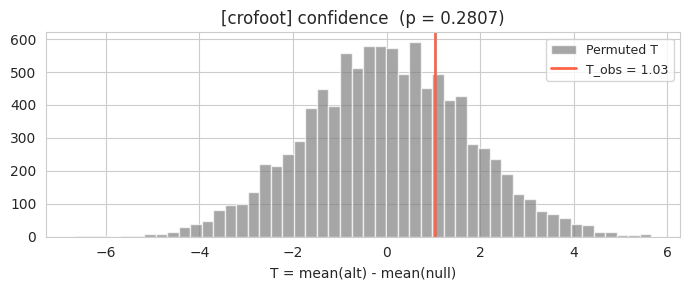

crofoot [confidence]: T=1.03  p=0.2807


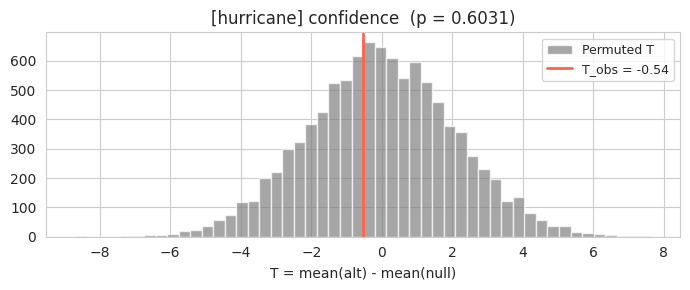

hurricane [confidence]: T=-0.54  p=0.6031


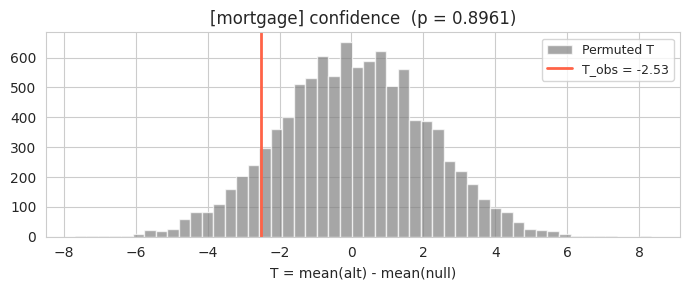

mortgage [confidence]: T=-2.53  p=0.8961


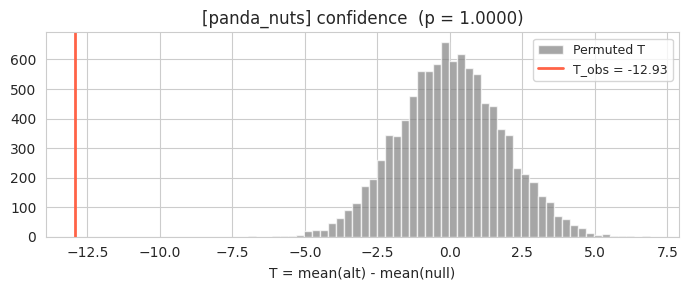

panda_nuts [confidence]: T=-12.93  p=1.0000


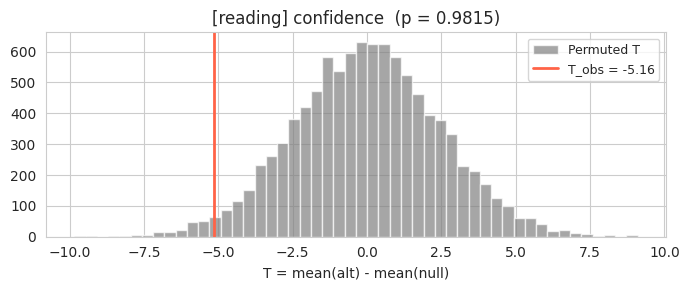

reading [confidence]: T=-5.16  p=0.9815


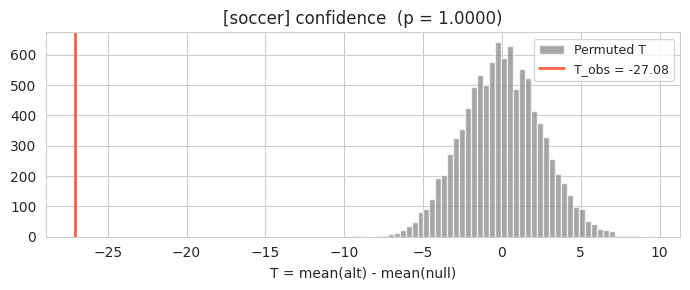

soccer [confidence]: T=-27.08  p=1.0000


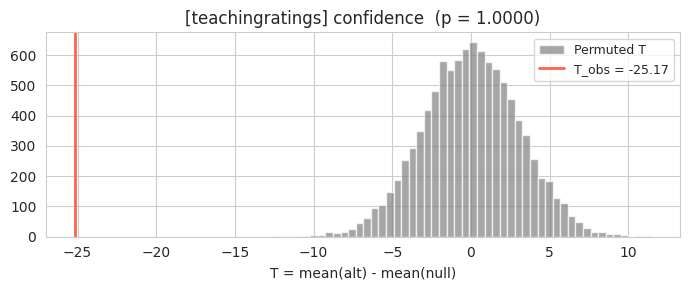

teachingratings [confidence]: T=-25.17  p=1.0000


In [9]:
rng = np.random.default_rng(42)
results = []

for score_col in ["response", "confidence"]:
    for dataset_name in datasets:
        sub = df[df["dataset"] == dataset_name]
        alt_vals = sub.loc[sub["distribution"] == "alt", score_col].values
        null_vals = sub.loc[sub["distribution"] == "null", score_col].values

        if len(alt_vals) < 2 or len(null_vals) < 2:
            continue

        t_obs, p_val, perm_ts = diff_in_means_perm_test(alt_vals, null_vals, rng=rng)

        results.append({
            "score": score_col,
            "dataset": dataset_name,
            "n_alt": len(alt_vals),
            "n_null": len(null_vals),
            "alt_mean": alt_vals.mean(),
            "null_mean": null_vals.mean(),
            "T_obs": t_obs,
            "p_value": p_val,
        })

        # permutation distribution plot
        fig, ax = plt.subplots(figsize=(7, 3))
        ax.hist(perm_ts, bins=50, color="gray", alpha=0.7, label="Permuted T")
        ax.axvline(t_obs, color="tomato", linewidth=2, label=f"T_obs = {t_obs:.2f}")
        ax.set_xlabel("T = mean(alt) - mean(null)")
        ax.set_title(f"[{dataset_name}] {score_col}  (p = {p_val:.4f})")
        ax.legend(fontsize=9)
        plt.tight_layout()
        plt.show()

        print(f"{dataset_name} [{score_col}]: T={t_obs:.2f}  p={p_val:.4f}")

## Summary

In [10]:
results_df = pd.DataFrame(results)

for score_col in ["response", "confidence"]:
    print(f"\n=== {score_col} ===")
    sub = results_df[results_df["score"] == score_col].drop(columns="score")
    print(sub.to_string(index=False))


=== response ===
        dataset  n_alt  n_null  alt_mean  null_mean      T_obs  p_value
        affairs     98      98 20.744898  30.765306 -10.020408 1.000000
           amtl     99      98 93.808081  26.632653  67.175428 0.000100
          boxes    100      98 34.460000  32.326531   2.133469 0.213179
      caschools     97      97 55.474227  17.381443  38.092784 0.000100
        crofoot     97      87 29.948454  24.620690   5.327764 0.000100
      hurricane     91      87 28.109890  21.137931   6.971959 0.000100
       mortgage     84      74 53.404762  30.513514  22.891248 0.000100
     panda_nuts     88      87 70.068182  30.149425  39.918757 0.000100
        reading     95      97 21.452632  24.556701  -3.104069 0.995500
         soccer     88      91 64.613636  23.186813  41.426823 0.000100
teachingratings     85      83 70.082353   7.373494  62.708859 0.000100

=== confidence ===
        dataset  n_alt  n_null  alt_mean  null_mean      T_obs  p_value
        affairs     98    